In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import plotly.express as px
import cufflinks as cf

from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

from plotly.offline import download_plotlyjs,init_notebook_mode,plot,iplot
init_notebook_mode(connected=True)
cf.go_offline()
from mpl_toolkits.mplot3d import Axes3D

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

import warnings
warnings.filterwarnings("ignore")
     

In [2]:
df = pd.read_csv("D:\\task2\\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
df_copy = df.copy()

In [4]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


In [6]:
df.duplicated().sum()

np.int64(0)

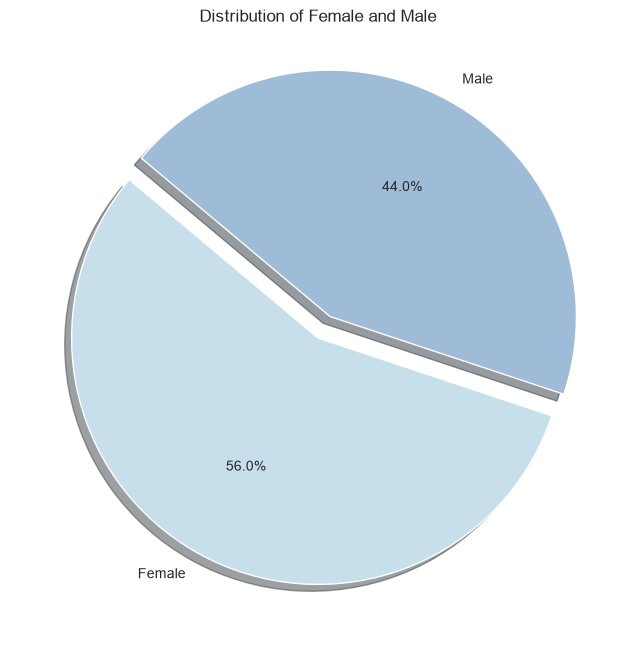

In [7]:
#VISUALIZATION
colors =sns.color_palette("ch:s=.25,rot=-.25")

# Pasta grafiği oluştur
plt.figure(figsize=(8, 8))
explode = (0, 0.1)
plt.pie(df['Gender'].value_counts(), explode=explode, labels=['Female', 'Male'], autopct='%1.1f%%',
        colors=colors, shadow=True, startangle=140)

# Grafiği düzenle
plt.title('Distribution of Female and Male')
plt.axis('off')
plt.show()

In [8]:
df['Gender Encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})
     

In [9]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Gender Encoded
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0


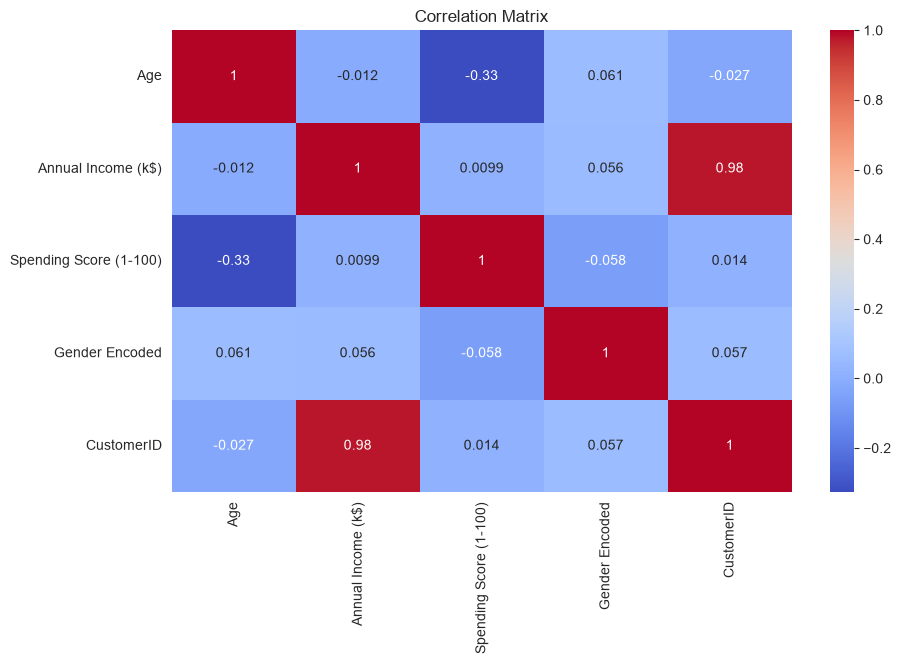

In [10]:
selected_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender Encoded', 'CustomerID']

correlation_matrix = df[selected_columns].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

In [11]:
df.drop("CustomerID", inplace=True, axis=1)

In [12]:
df.drop("Gender", inplace=True, axis=1)

In [13]:
df.head()

,Age,Annual Income (k$),Spending Score (1-100),Gender Encoded
0,19,15,39,1
1,21,15,81,1
2,20,16,6,0
3,23,16,77,0
4,31,17,40,0


In [14]:
df2_copy = df.copy()

In [15]:
#Scaling
from sklearn.preprocessing import StandardScaler
numeric_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
df_scaled = df[numeric_columns].copy()
scaler = StandardScaler()
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled)
df = df.drop(columns=numeric_columns)
# Concatenate the scaled numerical columns with the original dataset
df_std = pd.concat([df, df_scaled], axis=1)
print(df_std.head())

   Gender Encoded       Age  Annual Income (k$)  Spending Score (1-100)
0               1 -1.424569           -1.738999               -0.434801
1               1 -1.281035           -1.738999                1.195704
2               0 -1.352802           -1.700830               -1.715913
3               0 -1.137502           -1.700830                1.040418
4               0 -0.563369           -1.662660               -0.395980


In [16]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# Load your dataset from a CSV file
df = pd.read_csv("D:\\task2\\Mall_Customers.csv")

# Select the numerical columns to be scaled
numeric_columns = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

# Create a copy of the original numerical columns into a new DataFrame
df_scaled = df[numeric_columns].copy()

# Use MinMaxScaler to scale the selected numerical columns
scaler = MinMaxScaler()
df_scaled[numeric_columns] = scaler.fit_transform(df_scaled[numeric_columns])

# Drop the original numerical columns from the original dataset
df = df.drop(columns=numeric_columns)

# Concatenate the scaled numerical columns with the original dataset
df_min_max = pd.concat([df, df_scaled], axis=1)

# Display the modified dataset
print(df_min_max.head())


   CustomerID  Gender       Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male  0.019231            0.000000                0.387755
1           2    Male  0.057692            0.000000                0.816327
2           3  Female  0.038462            0.008197                0.051020
3           4  Female  0.096154            0.008197                0.775510
4           5  Female  0.250000            0.016393                0.397959


In [17]:
X1 = df_min_max[['Age', 'Annual Income (k$)']]
print(X1)
     

          Age  Annual Income (k$)
0    0.019231            0.000000
1    0.057692            0.000000
2    0.038462            0.008197
3    0.096154            0.008197
4    0.250000            0.016393
..        ...                 ...
195  0.326923            0.860656
196  0.519231            0.909836
197  0.269231            0.909836
198  0.269231            1.000000
199  0.230769            1.000000

[200 rows x 2 columns]


In [18]:
from sklearn.cluster import KMeans
ssd = []    # inertia  .. SSD, "Sum of Squared Distances"

K = range(2,10)

for k in K:
    model = KMeans(n_clusters =k, random_state=42)
    model.fit(X1)
    ssd.append(model.inertia_)
     

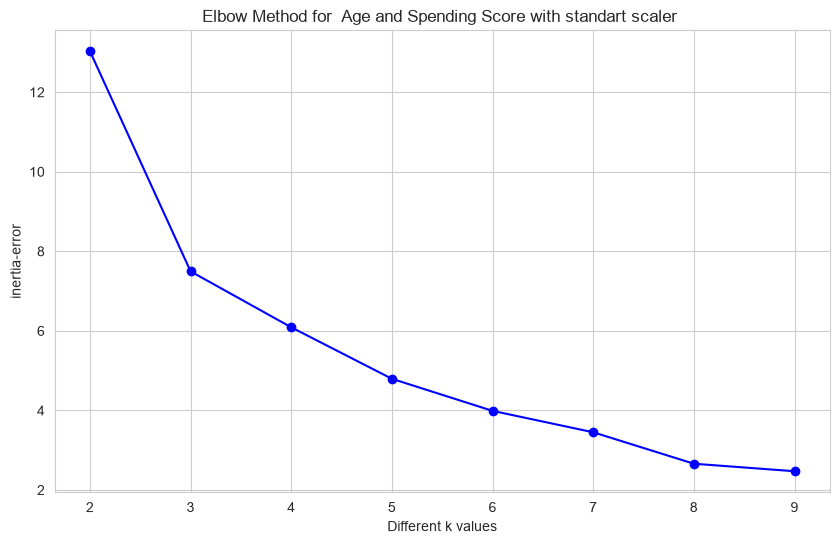

In [19]:
plt.plot(K, ssd, "bo-")
plt.xlabel("Different k values")
plt.ylabel("inertia-error")
plt.title("Elbow Method for  Age and Spending Score with standart scaler ")
plt.show()

In [20]:
df_diff =pd.DataFrame(-pd.Series(ssd).diff()).rename(index = lambda x : x+1)
df_diff

,0
1,NaN
2,5.535131
3,1.405966
4,1.294144
5,0.806411
6,0.537979
7,0.790825
8,0.188827


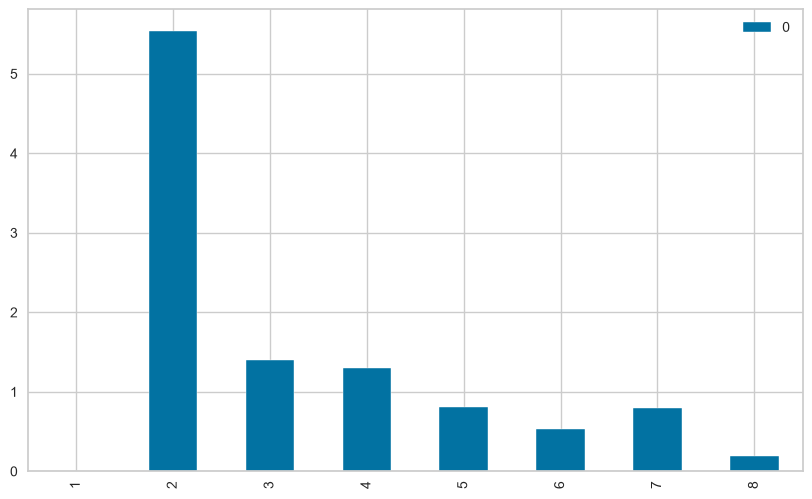

In [89]:

df_diff.plot(kind='bar');

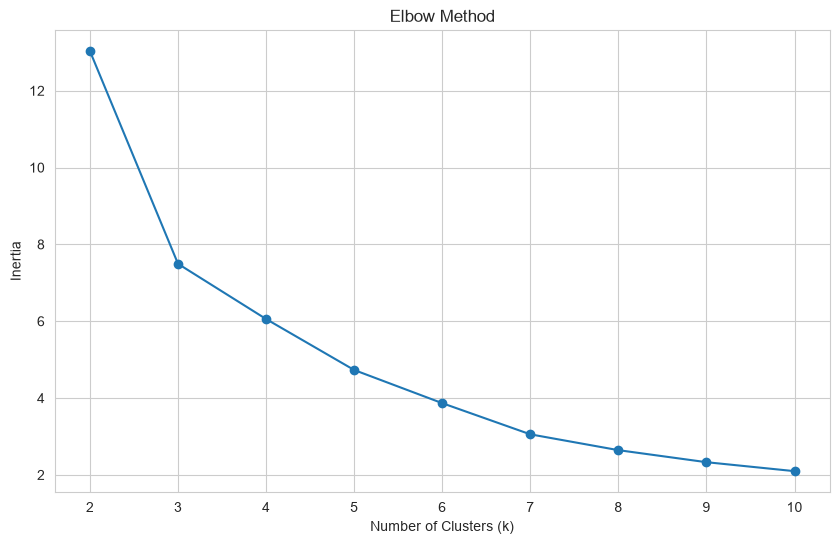

In [21]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X1)
    inertia.append(km.inertia_)

plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

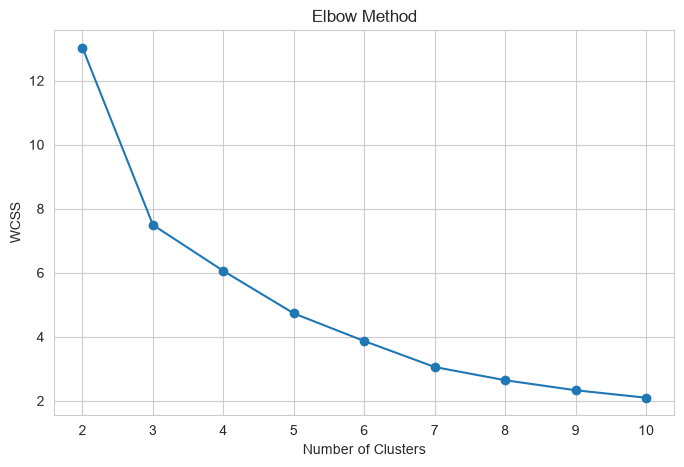

In [22]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(2, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X1)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(2, 11), wcss, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.title('Elbow Method')
plt.show()

In [23]:
from sklearn.metrics import silhouette_score

For n_clusters=2, the silhouette score is 0.4130
For n_clusters=3, the silhouette score is 0.4404
For n_clusters=4, the silhouette score is 0.3849
For n_clusters=5, the silhouette score is 0.3798
For n_clusters=6, the silhouette score is 0.3847
For n_clusters=7, the silhouette score is 0.4029
For n_clusters=8, the silhouette score is 0.4112


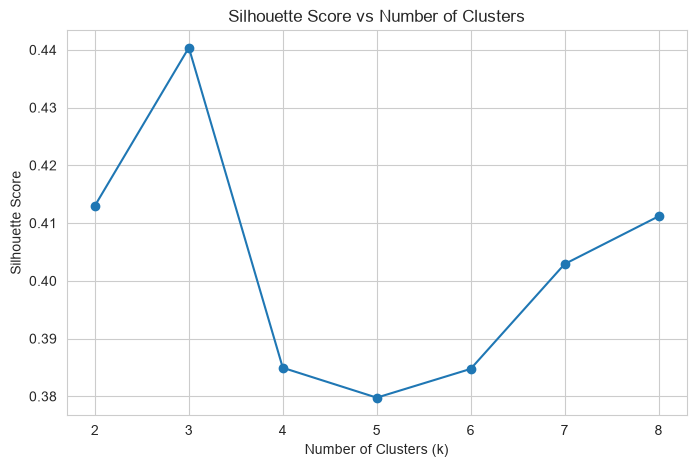

In [24]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

range_n_clusters = range(2, 9)
silhouette_scores = []

for num_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=num_clusters, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X1)

    score = silhouette_score(X1, cluster_labels)
    silhouette_scores.append(score)

    print(f"For n_clusters={num_clusters}, the silhouette score is {score:.4f}")

# Plot the silhouette scores
plt.figure(figsize=(8, 5))
plt.plot(range_n_clusters, silhouette_scores, marker='o', linestyle='-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score vs Number of Clusters')
plt.xticks(range_n_clusters)
plt.grid(True)
plt.show()

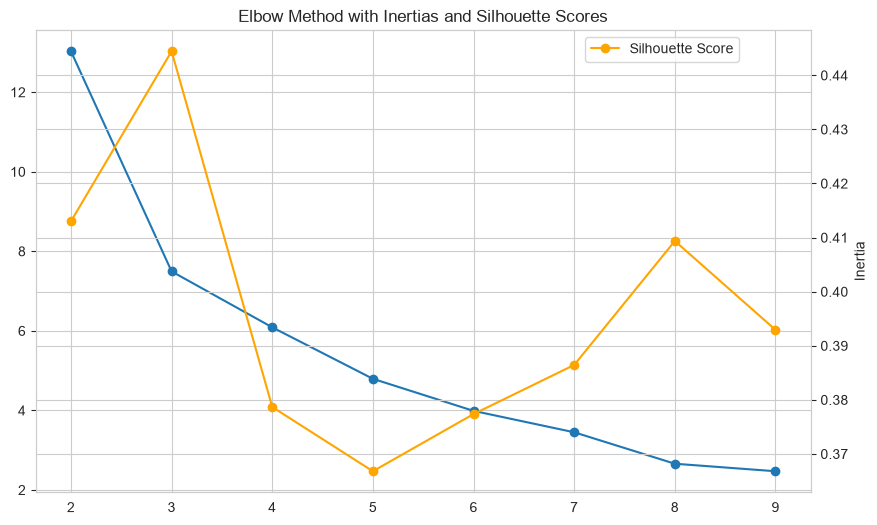

In [25]:
# Elbow ve Silhoutee skorunu bir arada gösteren grafik

inertia_scores = []
silhouette_scores = []
for i in range(2, 10):
    model = KMeans(n_clusters=i, random_state=42)
    labels = model.fit_predict(X1)
    silhouette = silhouette_score(X1, labels)
    inertia = model.inertia_
    inertia_scores.append(inertia)
    silhouette_scores.append(silhouette)
# Plotting the Elbow Method with Inertias and Silhouette Scores
plt.figure(figsize=(10, 6))
# Plot Inertias
plt.plot(range(2,10), inertia_scores, label='Inertia', marker='o')
# Plot Silhouette Scores on a secondary y-axis
plt.twinx()
plt.plot(range(2,10), silhouette_scores, label='Silhouette Score', marker='o', color='orange')
# Add labels, title, and legend
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method with Inertias and Silhouette Scores')
plt.legend(loc='upper left', bbox_to_anchor=(0.7, 1))
plt.show()

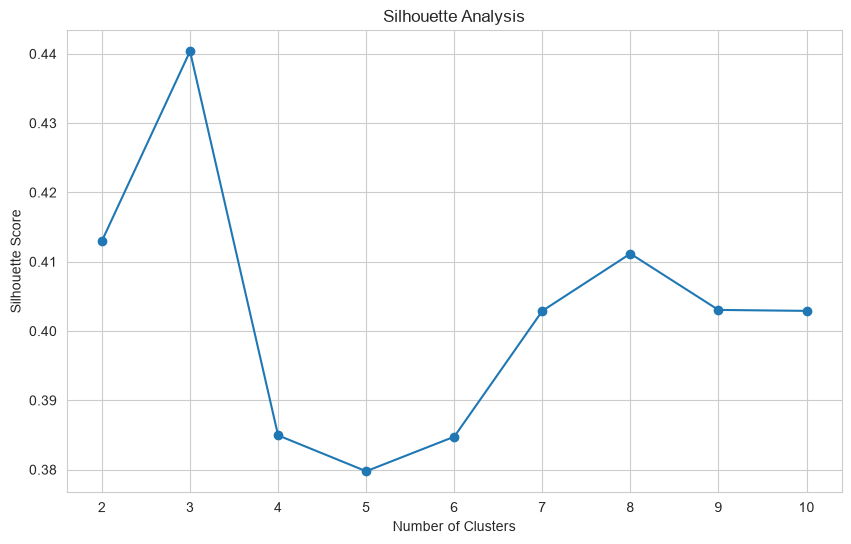

In [26]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X1)
    scores.append(silhouette_score(X1, labels))

plt.plot(range(2, 11), scores, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()